## **Interpretação do Modelo e Recomendações — Evasão Escolar**

Neste notebook traduzi os resultados do modelo em **insights acionáveis** para gestores escolares e secretarias de educação.

**Atividades:**
- Análise de perfil dos alunos em risco
- Simulação do sistema de classificação por nível de risco
- Recomendações práticas por fator de risco
- Limitações e próximos passos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')

COLOR_ALTO   = '#E74C3C'
COLOR_MEDIO  = '#F39C12'
COLOR_BAIXO  = '#2ECC71'
COLOR_MAIN   = '#2C3E50'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def save_fig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')

In [2]:
# Carregar dados e modelo
df         = pd.read_csv(DATA_DIR / 'evasao_escolar.csv')
pipeline   = joblib.load(MODELS_DIR / 'pipeline_xgb.pkl')
threshold  = joblib.load(MODELS_DIR / 'threshold_xgb.pkl')

# Recriar features de engenharia
df['media_notas']       = (df['nota_portugues'] + df['nota_matematica']) / 2
df['baixo_desempenho']  = ((df['nota_portugues'] < 5) | (df['nota_matematica'] < 5)).astype(int)
df['risco_faltas']      = (df['faltas_anuais'] > 15).astype(int)
df['risco_distorcao']   = (df['distorcao_idade_serie'] >= 2).astype(int)
df['engajamento']       = df['media_notas'] / (df['faltas_anuais'] + 1)

NUM_FEATURES = [
    'idade', 'nota_portugues', 'nota_matematica', 'media_notas',
    'distorcao_idade_serie', 'faltas_anuais', 'repeticoes_anteriores',
    'renda_familiar', 'trabalha', 'escolaridade_pai', 'escolaridade_mae',
    'baixo_desempenho', 'risco_faltas', 'risco_distorcao', 'engajamento'
]
CAT_FEATURES = ['serie', 'turno', 'sexo', 'raca_cor']

X = df[NUM_FEATURES + CAT_FEATURES]

# Score de risco para cada aluno
df['score_risco'] = pipeline.predict_proba(X)[:, 1]

print(f'Score médio de risco: {df["score_risco"].mean():.3f}')
df[['score_risco', 'evasao']].describe().round(3)

Score médio de risco: 0.352


,score_risco,evasao
count,15000.000,15000.000
mean,0.352,0.265
std,0.400,0.441
min,0.000,0.000
25%,0.005,0.000
50%,0.129,0.000
75%,0.800,1.000
max,1.000,1.000


## **Classificação por Nível de Risco:**

In [3]:
# Classificar em 3 níveis
def classificar_risco(score: float, thr: float) -> str:
    if score >= thr:
        return 'Alto'
    elif score >= thr * 0.65:
        return 'Médio'
    else:
        return 'Baixo'

df['nivel_risco'] = df['score_risco'].apply(
    lambda s: classificar_risco(s, threshold)
)

dist_risco = df['nivel_risco'].value_counts()
print('Distribuição por nível de risco:')
for nivel in ['Alto', 'Médio', 'Baixo']:
    n  = dist_risco[nivel]
    pct = n / len(df) * 100
    print(f'  {nivel:6s}: {n:,} alunos ({pct:.1f}%)')

Distribuição por nível de risco:
  Alto  : 5,508 alunos (36.7%)
  Médio : 708 alunos (4.7%)
  Baixo : 8,784 alunos (58.6%)


Salvo: ..\figures\11_distribuicao_risco.png


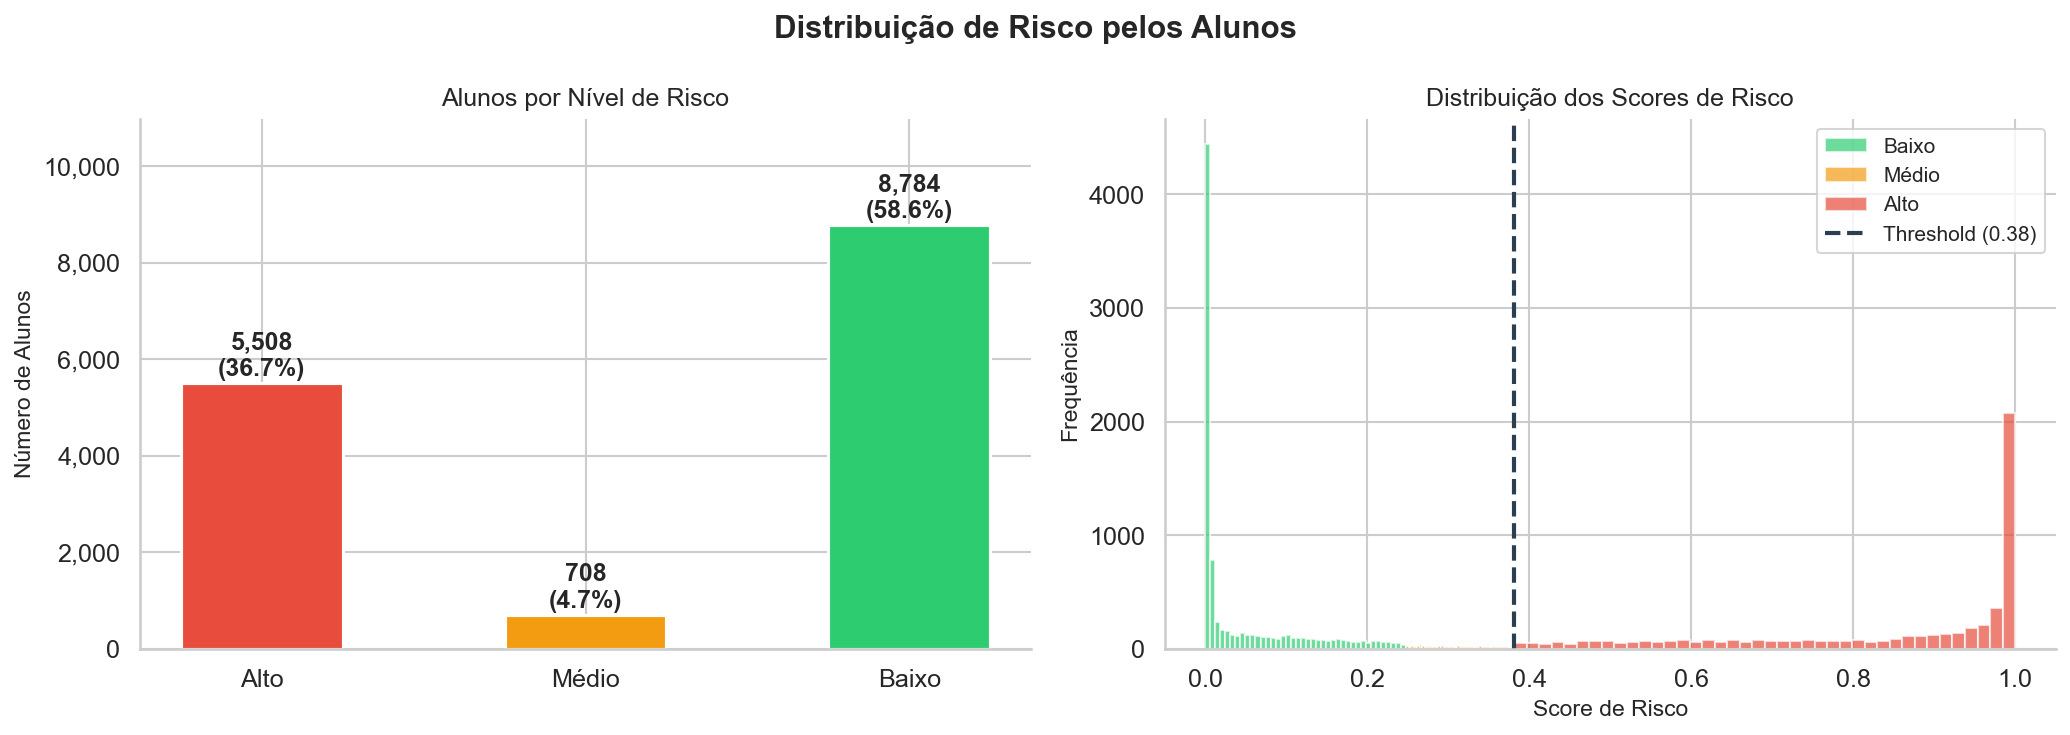

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Risco pelos Alunos',
             fontsize=15, fontweight='bold')

# Barras por nível
ax = axes[0]
niveis  = ['Alto', 'Médio', 'Baixo']
cores   = [COLOR_ALTO, COLOR_MEDIO, COLOR_BAIXO]
vals    = [dist_risco[n] for n in niveis]
bars = ax.bar(niveis, vals, color=cores, width=0.5,
              edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, vals, [v / len(df) * 100 for v in vals]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Alunos', fontsize=11)
ax.set_title('Alunos por Nível de Risco', fontsize=12)
ax.set_ylim(0, max(vals) * 1.25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Histograma do score
ax = axes[1]
ax.hist(df[df['nivel_risco'] == 'Baixo']['score_risco'],
        bins=40, alpha=0.7, color=COLOR_BAIXO, label='Baixo')
ax.hist(df[df['nivel_risco'] == 'Médio']['score_risco'],
        bins=40, alpha=0.7, color=COLOR_MEDIO, label='Médio')
ax.hist(df[df['nivel_risco'] == 'Alto']['score_risco'],
        bins=40, alpha=0.7, color=COLOR_ALTO, label='Alto')
ax.axvline(threshold, color=COLOR_MAIN, linestyle='--',
           linewidth=2, label=f'Threshold ({threshold:.2f})')
ax.set_xlabel('Score de Risco', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição dos Scores de Risco', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
save_fig('11_distribuicao_risco')
plt.show()

## **Perfil dos Alunos em Alto Risco:**

In [5]:
alto_risco = df[df['nivel_risco'] == 'Alto']
baixo_risco = df[df['nivel_risco'] == 'Baixo']

print('=== Perfil Médio: Alto Risco vs Baixo Risco ===')
comparativo = pd.DataFrame({
    'Alto Risco'  : alto_risco[NUM_FEATURES[:8]].mean(),
    'Baixo Risco' : baixo_risco[NUM_FEATURES[:8]].mean(),
}).round(2)
comparativo['Diferença'] = (comparativo['Alto Risco'] - comparativo['Baixo Risco']).round(2)
print(comparativo.to_string())

=== Perfil Médio: Alto Risco vs Baixo Risco ===
                       Alto Risco  Baixo Risco  Diferença
idade                       16.99        16.25       0.74
nota_portugues               5.38         6.40      -1.02
nota_matematica              4.79         6.52      -1.73
media_notas                  5.09         6.46      -1.37
distorcao_idade_serie        1.07         0.35       0.72
faltas_anuais               16.69        12.22       4.47
repeticoes_anteriores        0.38         0.03       0.35
renda_familiar            1706.92      1680.48      26.44


Salvo: ..\figures\12_taxa_real_por_nivel.png


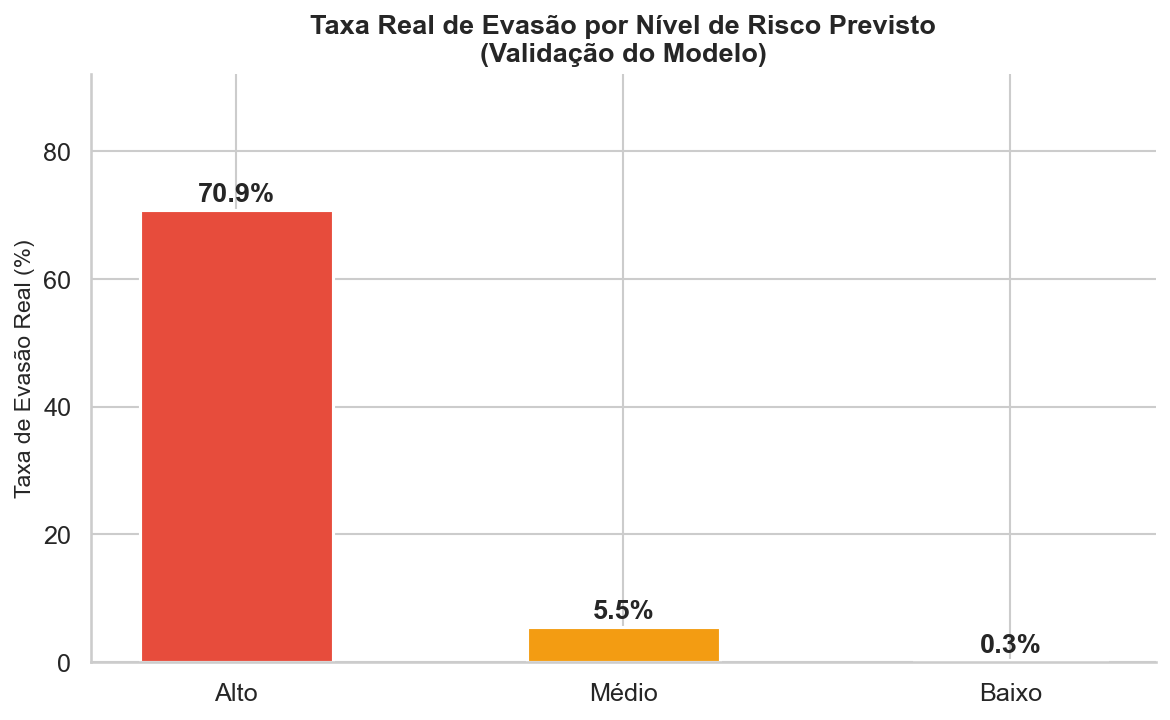

In [6]:
# Taxa de evasão real por nível de risco (validação do modelo)
taxa_real = df.groupby('nivel_risco')['evasao'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title('Taxa Real de Evasão por Nível de Risco Previsto\n(Validação do Modelo)',
             fontsize=13, fontweight='bold')

niveis_ord = ['Alto', 'Médio', 'Baixo']
bars = ax.bar(niveis_ord,
              [taxa_real.get(n, 0) for n in niveis_ord],
              color=[COLOR_ALTO, COLOR_MEDIO, COLOR_BAIXO],
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, nivel in zip(bars, niveis_ord):
    val = taxa_real.get(nivel, 0)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Taxa de Evasão Real (%)', fontsize=11)
ax.set_ylim(0, taxa_real.max() * 1.3)

plt.tight_layout()
save_fig('12_taxa_real_por_nivel')
plt.show()

## **Recomendações Práticas por Fator de Risco:**

Baseado na feature importance do modelo, os **5 principais fatores** e as ações recomendadas:

In [7]:
recomendacoes = [
    {
        'Fator'         : 'Distorção Idade-Série ≥ 2 anos',
        'Sinal de Alerta': 'Aluno com 2+ anos de atraso escolar',
        'Ação Recomendada': 'Encaminhar para programa de aceleração; acompanhamento pedagógico intensivo.',
        'Responsável'   : 'Coordenação Pedagógica',
    },
    {
        'Fator'         : 'Faltas Anuais > 20 dias',
        'Sinal de Alerta': 'Mais de 5 faltas no mês',
        'Ação Recomendada': 'Contato imediato com família; verificar causas (trabalho, saúde, transporte).',
        'Responsável'   : 'Assistente Social / Conselho Tutelar',
    },
    {
        'Fator'         : 'Nota de Matemática < 5',
        'Sinal de Alerta': 'Reprovação parcial em Matemática',
        'Ação Recomendada': 'Aulas de reforço; tutoria entre pares; identificar lacunas do Ensino Fundamental.',
        'Responsável'   : 'Professor de Matemática',
    },
    {
        'Fator'         : 'Trabalha (turno noturno)',
        'Sinal de Alerta': 'Aluno-trabalhador com frequência irregular',
        'Ação Recomendada': 'Flexibilização de prazos; apoio com material didático; parceria com empregador.',
        'Responsável'   : 'Direção Escolar',
    },
    {
        'Fator'         : 'Reprovações Anteriores ≥ 1',
        'Sinal de Alerta': 'Histórico de repetência',
        'Ação Recomendada': 'Psicopedagogia; verificar possível necessidade de suporte em saúde mental.',
        'Responsável'   : 'Equipe de Apoio Escolar',
    },
]

df_rec = pd.DataFrame(recomendacoes)
print(df_rec.to_string(index=False))

                         Fator                            Sinal de Alerta                                                                  Ação Recomendada                          Responsável
Distorção Idade-Série ≥ 2 anos        Aluno com 2+ anos de atraso escolar      Encaminhar para programa de aceleração; acompanhamento pedagógico intensivo.               Coordenação Pedagógica
       Faltas Anuais > 20 dias                    Mais de 5 faltas no mês     Contato imediato com família; verificar causas (trabalho, saúde, transporte). Assistente Social / Conselho Tutelar
        Nota de Matemática < 5           Reprovação parcial em Matemática Aulas de reforço; tutoria entre pares; identificar lacunas do Ensino Fundamental.              Professor de Matemática
      Trabalha (turno noturno) Aluno-trabalhador com frequência irregular   Flexibilização de prazos; apoio com material didático; parceria com empregador.                      Direção Escolar
    Reprovações Anteriores ≥ 1     

---
## 4 · Limitações e Próximos Passos

### Limitações
- **Dados sintéticos:** o modelo foi treinado em dados simulados com base em estatísticas agregadas. Resultados com microdados reais do INEP podem diferir.
- **Features ausentes:** variáveis como participação dos pais, transporte escolar, merenda e infraestrutura da escola não foram incluídas.
- **Viés histórico:** dados históricos refletem desigualdades sistêmicas; o modelo pode amplificar esses padrões.

### Próximos Passos

| Prioridade | Ação |
|------------|------|
|  Alta    | Validar com microdados reais do Censo Escolar 2022/2023 |
|  Alta    | Implementar API Flask/FastAPI para integração com sistemas escolares |
|  Média   | Adicionar explicabilidade (SHAP values) por aluno individual |
|  Média   | Dashboard Streamlit para gestores escolares |
|  Baixa   | Expandir para nível municipal (modelo por região) |

In [8]:
# Exportar tabela de scores para uso no dashboard futuro
df_export = df[['idade', 'serie', 'turno', 'score_risco', 'nivel_risco', 'evasao']].copy()
df_export.to_csv(DATA_DIR / 'alunos_com_risco.csv', index=False)
print(f'Exportado: {DATA_DIR}/alunos_com_risco.csv')
print(f'Shape: {df_export.shape}')
df_export.head()

Exportado: ..\data/alunos_com_risco.csv
Shape: (15000, 6)


,idade,serie,turno,score_risco,nivel_risco,evasao
0,17,3ano,matutino,0.001897,Baixo,0
1,16,2ano,matutino,0.940342,Alto,1
2,17,3ano,matutino,0.003936,Baixo,0
3,16,2ano,noturno,0.005046,Baixo,0
4,16,1ano,vespertino,0.040160,Baixo,0
